# Onboarding chats

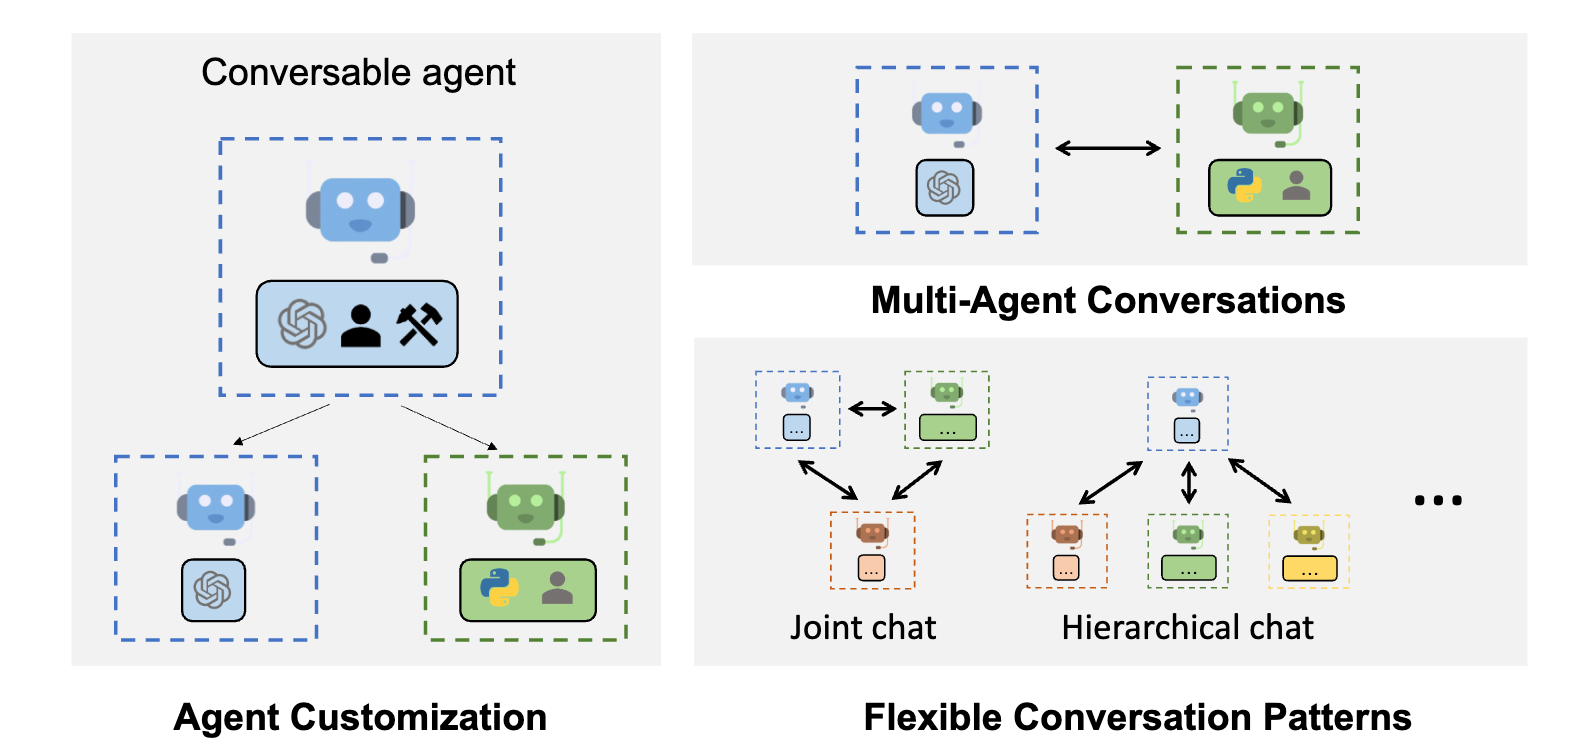

This example will cover how agents can be used to onboard users into a live chat system like the one you can find on an online app like your banking webiste or your phone provider webiste. We are going to use agents to gather specifc information about a user that needs help, we will then pass that information to human that will directly have a clear understanding of who requires help, where they're from and what their problem is, so that the human can immediately act on this information and help the user.

To do so, we are going to create 3 agents:
1. An **Onboarding Personal Information Agent**: this agent's goal is to get the name and location of the customer.
2. An **Onboarding Issue Agent**: this agent's goal is to determine what the issue of the customer is.
3. A  **Customer Engagement Agent**: this agent will interact with the customer until a human agent can start interacting with the customer.

To make things simpler, we will assume that these agents are deployed by a phone provider company called "ACME".

In [1]:
# We'll always have to start by creating a llm_config object to configure our agents
llm_config = {
    "model": "gpt-3.5-turbo", 
    }

## Agents definition

We will first start by defining our agents:

In [2]:
from autogen import ConversableAgent

/Users/jinhohyeon/Desktop/dev/Learned/llm/udemy-aiagents-building-teams-of-llm-agents/2/.venv/lib/python3.11/site-packages/flaml/__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")


The first agent is our **Onboarding Personal Information Agent**. Its main goal is to get the name and location of the customer. 

In [3]:
onboarding_personal_information_agent = ConversableAgent(
    name="Onboarding_Personal_Information_Agent",
    system_message='''You are a helpful customer onboarding agent,
    you work for a phone provider called ACME.
    Your job is to gather the customer's name and location.
    Do not ask for any other information, only ask about the customer's name and location.
    After the customer gives you their name and location, repeat them 
    and thank the user, and ask the user to answer with TERMINATE to move on to describing their issue.
    ''',
    llm_config=llm_config,
    human_input_mode="NEVER",
    is_termination_msg=lambda msg: "terminate" in msg.get("content").lower()
)

[autogen.oai.client: 03-17 22:59:13] {150} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.


The second agent is our **Onboarding Issue Agent**. Its main goal is to determine the issue the customer is facing with ACME's products.

In [4]:
onboarding_issue_agent = ConversableAgent(
    name="Onboarding_Issue_Agent",
    system_message='''You are a helpful customer onboarding agent,
    you work for a phone provider called ACME,
    you are here to help new customers get started with our product.
    Your job is to gather the product the customer use and the issue they currently 
    have with the product,
    Do not ask for other information.
    After the customer describes their issue, repeat it and add
    "Please answer with 'TERMINATE' if I have correctly understood your issue." ''',
    llm_config=llm_config,
    human_input_mode="NEVER",
    is_termination_msg=lambda msg: "terminate" in msg.get("content").lower()
)

[autogen.oai.client: 03-17 22:59:16] {150} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.


The third agent is our **Customer Engagement Agent**. Its main goal is to interact with the customer based on the previously gathered information until a human agent can start intertacting with the customer to solve their issue.

In [5]:
customer_engagement_agent = ConversableAgent(
    name="Customer_Engagement_Agent",
    system_message='''You are a helpful customer service agent.
    Your job is to gather customer's preferences on news topics.
    You are here to provide fun and useful information to the customer based on the user's
    personal information and topic preferences.
    This could include fun facts, jokes, or interesting stories.
    Make sure to make it engaging and fun!
    Return 'TERMINATE' when you are done.''',
    llm_config=llm_config,
    human_input_mode="NEVER",
    is_termination_msg=lambda msg: "terminate" in msg.get("content").lower(),
)

[autogen.oai.client: 03-17 22:59:20] {150} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.


Finally, this time, we will also have to define a **customer proxy agent**. The customer proxy agent is a Conversable Agent that is not an LLM (`llm_config=False`), it will however have the `human_input_mode="ALWAYS"` which means that you, the human, will play the role of this agent. You will be the customer through this agent.

In [6]:
customer_proxy_agent = ConversableAgent(
    name="customer_proxy_agent",
    llm_config=False,
    code_execution_config=False,
    human_input_mode="ALWAYS",
)

Alright, that's all for our agents!  

The next step is now to orchestrate the chat

## Chat orchestration

We are now going to define how the chat will happen. This means that we will define in which order agents will interact and who'll interact with who when. To define this, we will use a list, that will contain several elements, each one corresponding to a chat. The chats will then happen in that specific order.

Let's define a `chat` object and then the first chat:

In [7]:
chats = [] # This is going to be our list of chats

### 1. Onboarding Agent with Customer

We will now define the first chat and add it to this list. The first chat will be between our first agent, the **Onboarding Personal Information Agent** and the **customer**, who is going to be us.

The first message will be sent by the **Onboarding Personal Information Agent** and will be:
> *Hello, I'm here to help you get started with our product. 
            Could you tell me your name?*

#### Carrying data to the next chat

In order to make the transition easier with the next agent, we are going to ask for a slightly different type of summary than we did before with this agent. We are going to request a summary generated by the LLM, but **we will specify that the summary should return the name and location of the customer in a JSON format:** `{'name': '', 'location': ''}`. This is a structured data format that can be easily read by another agent but **also by another app or protocol**. This shows how an LLM agent can be used to interact with other apps.

Since we only want to transfer name and location to the next chat and we specifically specified how we want to transfer this data, we are going to add a new parameter, the `clear_history` to `True` which means that no data other than the one specified in the summary will be sent to the next chat. If we set it to `False` the agent from the next chat will be aware about the previous exchange with the user. We'll use that later.

In [8]:
chats.append(
    {
        "sender": onboarding_personal_information_agent,
        "recipient": customer_proxy_agent,
        "message": 
            "Hello, I'm here to help you solve any issue you have with our products. "
            "Could you tell me your name?",
        "summary_method": "reflection_with_llm",
        "summary_args": {
        "summary_prompt" : "Return the customer information "
                             "into a JSON object only: "
                             "{'name': '', 'location': ''}",
        },
        "clear_history" : True
    }
)

### 2. Issue Agent with Customer

We will now define the second chat and add it to this list. The second chat will be between our second agent, the **Issue Agent** and the **customer**, who is going to be us again.

The second message will be sent by the **Onboarding Personal Information Agent** and will be:
> *Great! Could you tell me what issue you're currently having and with which product?*

This time we're going to generate a summary, but we won't specify any format or specifc fata that must be carried over because we do not know what the exchange will yield specifically. We are also going to specify that we want to transfer the chat history to the next chat/agent.

In [9]:
chats.append(
    {
        "sender": onboarding_issue_agent,
        "recipient": customer_proxy_agent,
        "message": 
                "Great! Could you tell me what issue you're "
                "currently having and with which product?",
        "summary_method": "reflection_with_llm",
        "clear_history" : False
    }
)

### 3. Customer Engagement Agent with Customer

We will now define the third chat and add it to this list. The third chat will be between our third agent, the **Customer Engagement Agent** and the **customer**, who is going to be us again.

The third message will be sent by the **Customer Engagement Agent** and will be:
> *Can you tell me more about how you use our products or some topics interesting for you?*

This time we're going to generate a summary so that the human agent can get this information in an easy and quick way when they take over the conversation, but we won't specify any format or specifc fata that must be carried over because we do not know what the exchange will yield specifically. 

In [10]:
chats.append(
        {
        "sender": customer_proxy_agent,
        "recipient": customer_engagement_agent,
        "message": "While we're waiting for a human agent to take over and help you solve "
        "your issue, can you tell me more about how you use our products or some "
        "topics interesting for you?",
        "max_turns": 2,
        "summary_method": "reflection_with_llm",
    }
)
chats

[{'sender': <autogen.agentchat.conversable_agent.ConversableAgent at 0x106098550>,
  'recipient': <autogen.agentchat.conversable_agent.ConversableAgent at 0x10d60b950>,
  'message': "Hello, I'm here to help you solve any issue you have with our products. Could you tell me your name?",
  'summary_method': 'reflection_with_llm',
  'summary_args': {'summary_prompt': "Return the customer information into a JSON object only: {'name': '', 'location': ''}"},
  'clear_history': True},
 {'sender': <autogen.agentchat.conversable_agent.ConversableAgent at 0x10d60b910>,
  'recipient': <autogen.agentchat.conversable_agent.ConversableAgent at 0x10d60b950>,
  'message': "Great! Could you tell me what issue you're currently having and with which product?",
  'summary_method': 'reflection_with_llm',
  'clear_history': False},
 {'sender': <autogen.agentchat.conversable_agent.ConversableAgent at 0x10d60b950>,
  'recipient': <autogen.agentchat.conversable_agent.ConversableAgent at 0x10d62ebd0>,
  'message

## Initiate the sequential chat

Now that we finished orchestrating the chat, we can get it started!  
For this to work, **you**, the customer, will have to roleplay as a customer that currently have an issue with your phone provider. Let's say that your internet does not work, or that you want more bandwidth, or that you want some help to setup port forwarding to play a game with some friends or some other thing. Have fun doing some roleplay!  

In [11]:
from autogen import initiate_chats

chat_results = initiate_chats(chats)


********************************************************************************
Starting a new chat....

********************************************************************************
Onboarding_Personal_Information_Agent (to customer_proxy_agent):

Hello, I'm here to help you solve any issue you have with our products. Could you tell me your name?

--------------------------------------------------------------------------------


/Users/jinhohyeon/Desktop/dev/Learned/llm/udemy-aiagents-building-teams-of-llm-agents/2/.venv/lib/python3.11/site-packages/autogen/agentchat/chat.py:47: UserWarning: Repetitive recipients detected: The chat history will be cleared by default if a recipient appears more than once. To retain the chat history, please set 'clear_history=False' in the configuration of the repeating agent.
  warnings.warn(



>>>>>>>> NO HUMAN INPUT RECEIVED.

>>>>>>>> USING AUTO REPLY...
customer_proxy_agent (to Onboarding_Personal_Information_Agent):



--------------------------------------------------------------------------------
Onboarding_Personal_Information_Agent (to customer_proxy_agent):

Thank you. Can you also share your current location with me, please?

--------------------------------------------------------------------------------

>>>>>>>> NO HUMAN INPUT RECEIVED.

>>>>>>>> USING AUTO REPLY...
customer_proxy_agent (to Onboarding_Personal_Information_Agent):



--------------------------------------------------------------------------------
Onboarding_Personal_Information_Agent (to customer_proxy_agent):

Thank you, I have noted down your name and location. I appreciate your help. To proceed further, could you please answer with TERMINATE to proceed to describing your issue?

--------------------------------------------------------------------------------

>>>>>>>> NO HUMAN INPUT RECEIVED.

And that's all for the exchange! It could go on for lonjger, but remember that we specified a `max_turns` settings for each chat, there is no need to let this last for too long since we're just running examples.

Now once the human agent is ready to take over the conversation, we can provide them with a summary of all the information necessary so that they can immediately get started with solving the issue of the customer using the following commads, as we previously explored:

In [12]:
import pprint

for chat_result in chat_results:
    #pprint.pprint(chat_result.chat_history) # We could also get the whole chat history with this command
    pprint.pprint(chat_result.summary)

'{\n    "name": "",\n    "location": ""\n}'
('The user is experiencing an issue with a product but did not specify the '
 'details. They requested assistance with a specific problem but explained it '
 'generically.')
("Let's talk about interesting facts about technology and innovation, such as "
 'the first computer virus created in the 1970s and the first camera phone '
 'sold in 2000 by J-Phone in Japan. Feel free to share any specific topics '
 "you're curious about.")


The human can thus quickly learn about our customer, their name, location and issue and immediately get started on solving the issue.

## What is this for?

This example shows you how you can integrate LLMs into an app in order to accomplish complex interactions with humans and gather specific information through natural communication. This is very powerful and is not something that was easy to do it before having LLMs. By having agents focused on a single task, we're able to ensure that the LLM won't diverge and remain focused on a simple task, greatly increasing chances that it accurately accomplishes it.